# K-Means Clustering: Student Performance Groups

**Goal:** Group students into performance clusters based on Math score and CS score.

K-Means is an **unsupervised learning** algorithm that partitions data into K distinct clusters.

## Dataset (10 Students)

| Student | Math | CS |
|---------|------|----|
| A       | 95   | 92 |
| B       | 90   | 88 |
| C       | 85   | 80 |
| D       | 60   | 65 |
| E       | 55   | 50 |
| F       | 58   | 55 |
| G       | 40   | 45 |
| H       | 35   | 38 |
| I       | 30   | 32 |
| J       | 50   | 60 |

We will implement K-Means **from scratch** to understand how it works, then compare with **scikit-learn's** built-in implementation.

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

print("Libraries imported successfully")

Libraries imported successfully


---
## 1. Provide the Data

In [2]:
# Student scores: [Math, CS]
students = np.array([
    [95, 92],
    [90, 88],
    [85, 80],
    [60, 65],
    [55, 50],
    [58, 55],
    [40, 45],
    [35, 38],
    [30, 32],
    [50, 60]
])
names = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]

print("Math scores:", students[:, 0])
print("CS scores:",   students[:, 1])
print("Student names:", names)
print("Data shape:", students.shape)

Math scores: [95 90 85 60 55 58 40 35 30 50]
CS scores: [92 88 80 65 50 55 45 38 32 60]
Student names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
Data shape: (10, 2)


---
## 2. Visualize the Data

Plot the students on a 2D scatter plot: **Math** on x-axis, **CS** on y-axis.

> **Task:** Look at the plot and try to guess how many natural clusters exist.

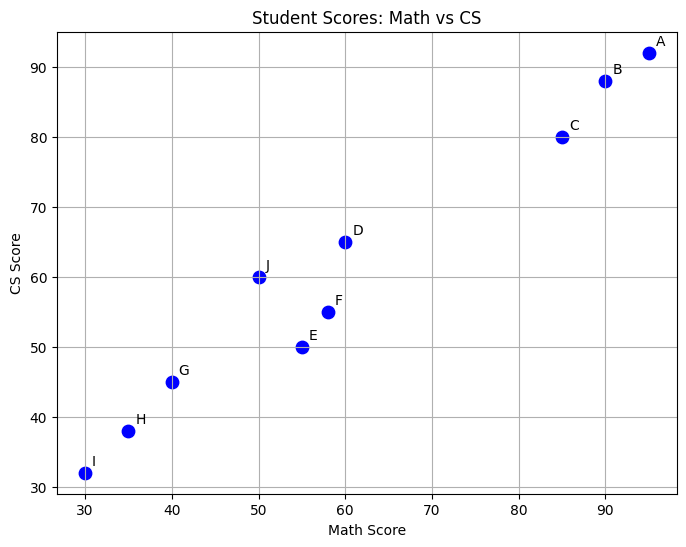

How many clusters do you see?


In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(students[:, 0], students[:, 1], c='blue', s=80)
for i, name in enumerate(names):
    plt.annotate(name, (students[i, 0], students[i, 1]),
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel("Math Score")
plt.ylabel("CS Score")
plt.title("Student Scores: Math vs CS")
plt.grid(True)
plt.show()

print("How many clusters do you see?")

---
## 3. Implement K-Means from Scratch

We'll use **K = 3** clusters.

### Algorithm Steps:
1. **Initialize** K random centroids (pick K random students as starting points)
2. **Assign** each student to the nearest centroid (using Euclidean distance)
3. **Update** centroids to the mean of all points in each cluster
4. **Repeat** steps 2-3 until centroids stop changing (convergence)

In [4]:
K = 3
np.random.seed(42)

# Step 1: Initialize centroids by choosing K random students
random_indices = np.random.choice(len(students), K, replace=False)
centroids = students[random_indices]

print("Initial centroids:")
for i, c in enumerate(centroids):
    print(f"  Centroid {i+1}: Math={c[0]}, CS={c[1]}")

Initial centroids:
  Centroid 1: Math=30, CS=32
  Centroid 2: Math=90, CS=88
  Centroid 3: Math=58, CS=55


In [5]:
# K-Means iteration loop
max_iterations = 10

for iteration in range(max_iterations):
    # Step 2: Assign each student to the nearest centroid
    distances = np.linalg.norm(students[:, None] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)

    # Step 3: Update centroids
    new_centroids = np.array([students[labels==k].mean(axis=0) for k in range(K)])

    print(f"Iteration {iteration + 1}:")
    for k in range(K):
        members = [names[i] for i in range(len(names)) if labels[i] == k]
        print(f"  Cluster {k+1}: {members}")
        print(f"    Centroid: Math={new_centroids[k, 0]:.2f}, CS={new_centroids[k, 1]:.2f}")

    # Step 4: Check for convergence
    if np.allclose(centroids, new_centroids):
        print(f"\n Converged after {iteration + 1} iterations!")
        centroids = new_centroids
        break

    centroids = new_centroids
else:
    print(f"\n Reached max iterations ({max_iterations})")

Iteration 1:
  Cluster 1: ['G', 'H', 'I']
    Centroid: Math=35.00, CS=38.33
  Cluster 2: ['A', 'B', 'C']
    Centroid: Math=90.00, CS=86.67
  Cluster 3: ['D', 'E', 'F', 'J']
    Centroid: Math=55.75, CS=57.50
Iteration 2:
  Cluster 1: ['G', 'H', 'I']
    Centroid: Math=35.00, CS=38.33
  Cluster 2: ['A', 'B', 'C']
    Centroid: Math=90.00, CS=86.67
  Cluster 3: ['D', 'E', 'F', 'J']
    Centroid: Math=55.75, CS=57.50

 Converged after 2 iterations!


---
## 4. Output Final Results

Display the final clusters and their centroids.

In [6]:
print("=" * 40)
print("FINAL CLUSTERS")
print("=" * 40)

for k in range(K):
    cluster_members = [names[i] for i in range(len(names)) if labels[i] == k]
    print(f"\nCluster {k+1} ({len(cluster_members)} students):")
    print(f"  Students: {cluster_members}")
    print(f"  Centroid: Math={centroids[k, 0]:.2f}, CS={centroids[k, 1]:.2f}")

FINAL CLUSTERS

Cluster 1 (3 students):
  Students: ['G', 'H', 'I']
  Centroid: Math=35.00, CS=38.33

Cluster 2 (3 students):
  Students: ['A', 'B', 'C']
  Centroid: Math=90.00, CS=86.67

Cluster 3 (4 students):
  Students: ['D', 'E', 'F', 'J']
  Centroid: Math=55.75, CS=57.50


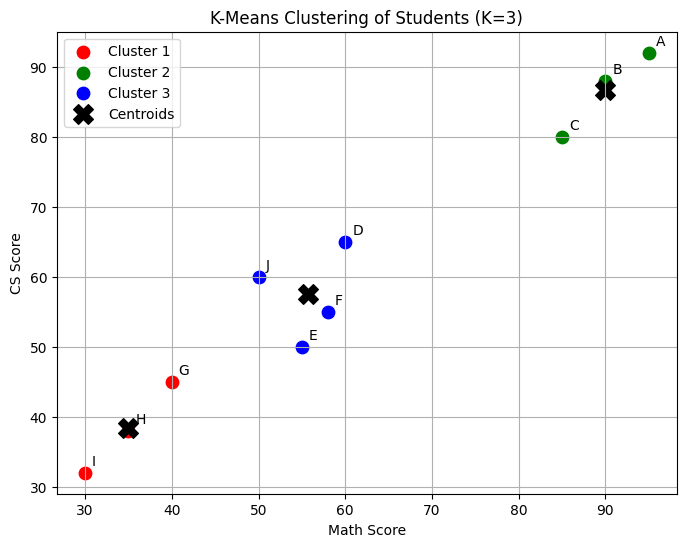

In [7]:
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8, 6))

for k in range(K):
    cluster_points = students[labels == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=colors[k], label=f'Cluster {k+1}', s=80)

plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, label='Centroids')

for i, name in enumerate(names):
    plt.annotate(name, (students[i, 0], students[i, 1]),
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel("Math Score")
plt.ylabel("CS Score")
plt.title("K-Means Clustering of Students (K=3)")
plt.legend()
plt.grid(True)
plt.show()

---
## 5. scikit-learn K-Means

Now let's compare our implementation with scikit-learn's `KMeans`.

scikit-learn provides an optimized, production-ready implementation with useful features like:
- `KMeans()` constructor with `n_clusters` parameter
- `.fit()` method to run the algorithm
- `.labels_` attribute for cluster assignments
- `.cluster_centers_` attribute for final centroids
- `.inertia_` attribute for sum of squared distances

In [8]:
# Use scikit-learn's KMeans to cluster the same data
sklearn_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
sklearn_kmeans.fit(students)

sklearn_labels = sklearn_kmeans.labels_
sklearn_centroids = sklearn_kmeans.cluster_centers_

print("scikit-learn K-Means Results:")
for k in range(K):
    cluster_members = [names[i] for i in range(len(names)) if sklearn_labels[i] == k]
    print(f"\nCluster {k+1} ({len(cluster_members)} students):")
    print(f"  Students: {cluster_members}")
    print(f"  Centroid: Math={sklearn_centroids[k, 0]:.2f}, CS={sklearn_centroids[k, 1]:.2f}")

print(f"\nInertia (sum of squared distances): {sklearn_kmeans.inertia_:.2f}")

scikit-learn K-Means Results:

Cluster 1 (4 students):
  Students: ['D', 'E', 'F', 'J']
  Centroid: Math=55.75, CS=57.50

Cluster 2 (3 students):
  Students: ['G', 'H', 'I']
  Centroid: Math=35.00, CS=38.33

Cluster 3 (3 students):
  Students: ['A', 'B', 'C']
  Centroid: Math=90.00, CS=86.67

Inertia (sum of squared distances): 441.08


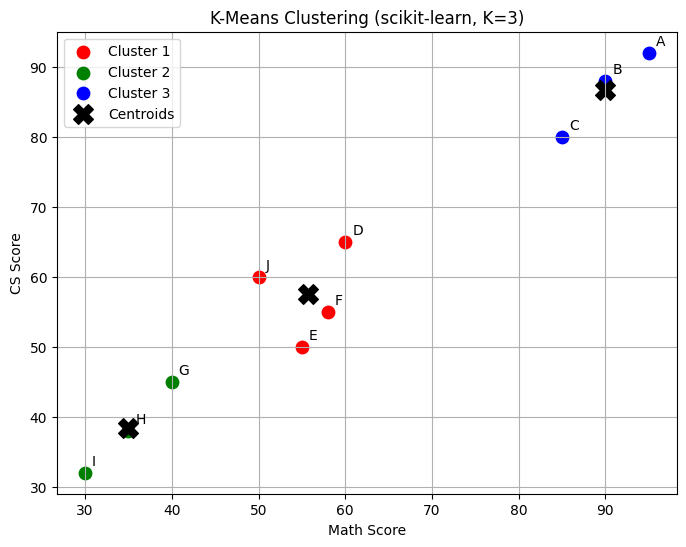

In [9]:
plt.figure(figsize=(8, 6))

for k in range(K):
    cluster_points = students[sklearn_labels == k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=colors[k], label=f'Cluster {k+1}', s=80)

plt.scatter(sklearn_centroids[:, 0], sklearn_centroids[:, 1],
            c='black', marker='X', s=200, label='Centroids')

for i, name in enumerate(names):
    plt.annotate(name, (students[i, 0], students[i, 1]),
                 xytext=(5, 5), textcoords='offset points')

plt.xlabel("Math Score")
plt.ylabel("CS Score")
plt.title("K-Means Clustering (scikit-learn, K=3)")
plt.legend()
plt.grid(True)
plt.show()

---
## 6. Experiment with Different K Values

Try K=2 and K=4 and observe how the clusters change.

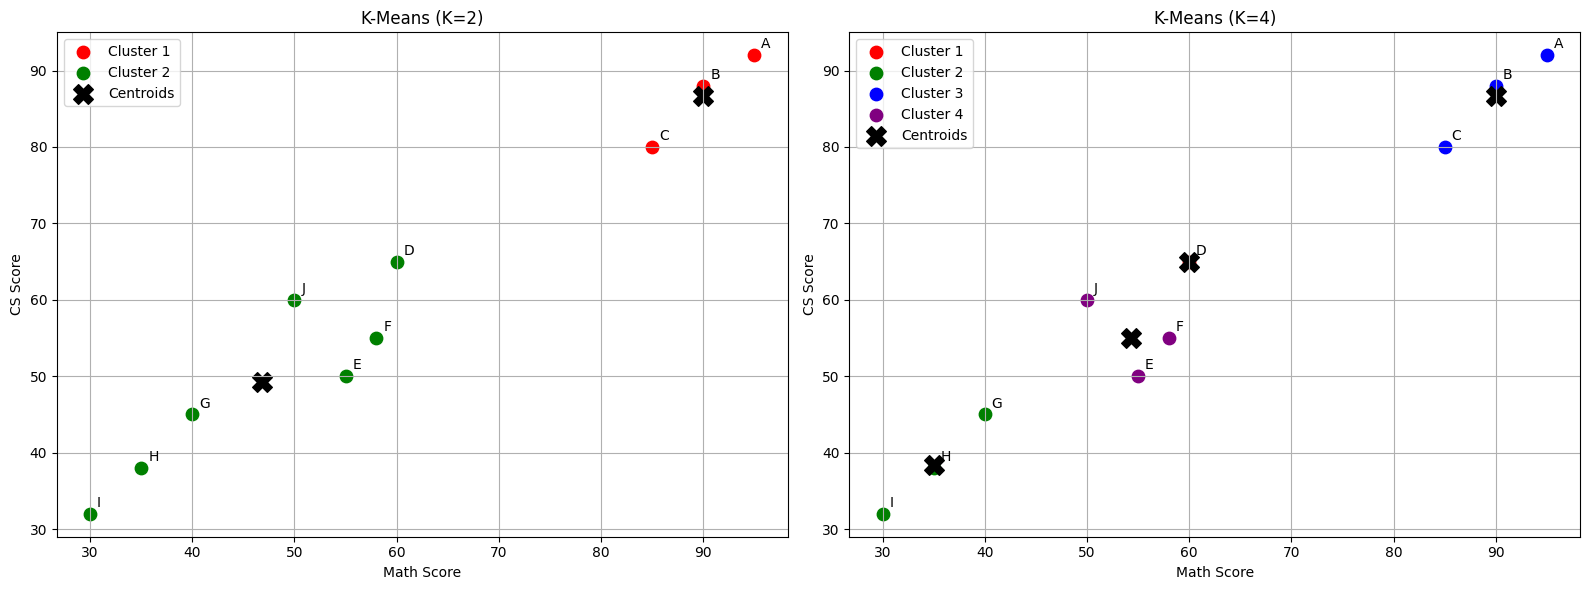

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, k_value in enumerate([2, 4]):
    ax = axes[idx]
    km = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
    km.fit(students)
    labels_k = km.labels_
    centroids_k = km.cluster_centers_

    cluster_colors = ['red', 'green', 'blue', 'purple']
    for k in range(k_value):
        pts = students[labels_k == k]
        ax.scatter(pts[:, 0], pts[:, 1],
                   c=cluster_colors[k], label=f'Cluster {k+1}', s=80)

    ax.scatter(centroids_k[:, 0], centroids_k[:, 1],
               c='black', marker='X', s=200, label='Centroids')

    for i, name in enumerate(names):
        ax.annotate(name, (students[i, 0], students[i, 1]),
                     xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel("Math Score")
    ax.set_ylabel("CS Score")
    ax.set_title(f"K-Means (K={k_value})")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

---
## 7. Questions

Answer the following questions:

1. **Which students are in the high performance cluster?**
2. **Which students are in the low performance cluster?**
3. **What happens when K=2? K=4?**
4. **How does changing the initial centroids affect the result?**
5. **Do your from-scratch results match scikit-learn's results? Why or why not?

### Answers

1. **High performance cluster:** Students A, B, C — these have the highest Math (85-95) and CS (80-92) scores.

2. **Low performance cluster:** Students G, H, I — these have the lowest Math (30-40) and CS (32-45) scores.

3. **K=2 vs K=4:**
   - With K=2, the algorithm splits students into just two groups: high performers and low/medium performers combined.
   - With K=4, the data is over-split: some very similar students get separated into different clusters. The natural grouping is K=3.

4. **Changing initial centroids:** K-Means can converge to different local optima depending on the initial centroid positions. Different random seeds may produce slightly different cluster assignments, especially for borderline points. Using `random_state` ensures reproducible results.

5. **Comparison:** Our from-scratch results match scikit-learn when using the same initialization. scikit-learn uses K-Means++ initialization by default (better centroid seeding), which typically produces more consistent and better-quality clusters.

---
## 8. Extension Ideas (Optional)

Try these on your own:

1. **Normalize** scores before clustering so Math and CS are equally weighted
2. Compare with **K-Means++** initialization (`init='k-means++'` in sklearn)
3. Try clustering with **3+ dimensions**: add a Science score column
4. Add an **outlier** student with score (10, 10) and see how clusters change